In [2]:
import pandas as pd

# باز کردن فایل خام
with open("01013500_streamflow_qc.txt", "r") as f:
    lines = f.readlines()

# فقط خطوطی که با عدد شروع می‌شن
data_lines = [line for line in lines if line.strip() and line.strip()[0].isdigit()]

# ذخیره فایل تمیز
with open("clean_streamflow.txt", "w") as f:
    f.writelines(data_lines)

# خواندن با پانداس
df = pd.read_csv("clean_streamflow.txt", sep=r"\s+", header=None,
                 names=["basin", "year", "month", "day", "streamflow", "flag"])

# تبدیل دبی به عدد و حذف NaN
df["streamflow"] = pd.to_numeric(df["streamflow"], errors="coerce")
df = df.dropna()

In [6]:
print("تعداد کل سطرها:", len(df))
df.head()

تعداد کل سطرها: 12784


,basin,year,month,day,streamflow,flag
date,,,,,,
1980-01-01,1013500,1980,1,1,655.0,A
1980-01-02,1013500,1980,1,2,640.0,A
1980-01-03,1013500,1980,1,3,625.0,A
1980-01-04,1013500,1980,1,4,620.0,A
1980-01-05,1013500,1980,1,5,605.0,A


In [3]:
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df = df.set_index("date")
df = df.sort_index()

In [7]:
print("از:", df.index.min().date())
print("تا:", df.index.max().date())

از: 1980-01-01
تا: 2014-12-31


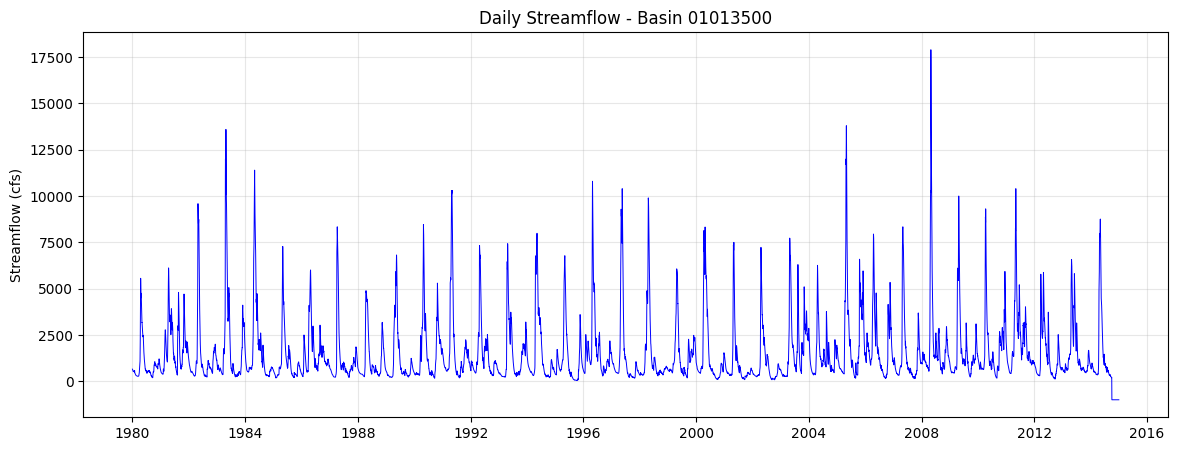

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["streamflow"], color="blue", linewidth=0.7)
plt.title("Daily Streamflow - Basin 01013500")
plt.ylabel("Streamflow (cfs)")
plt.grid(True, alpha=0.3)
plt.show()

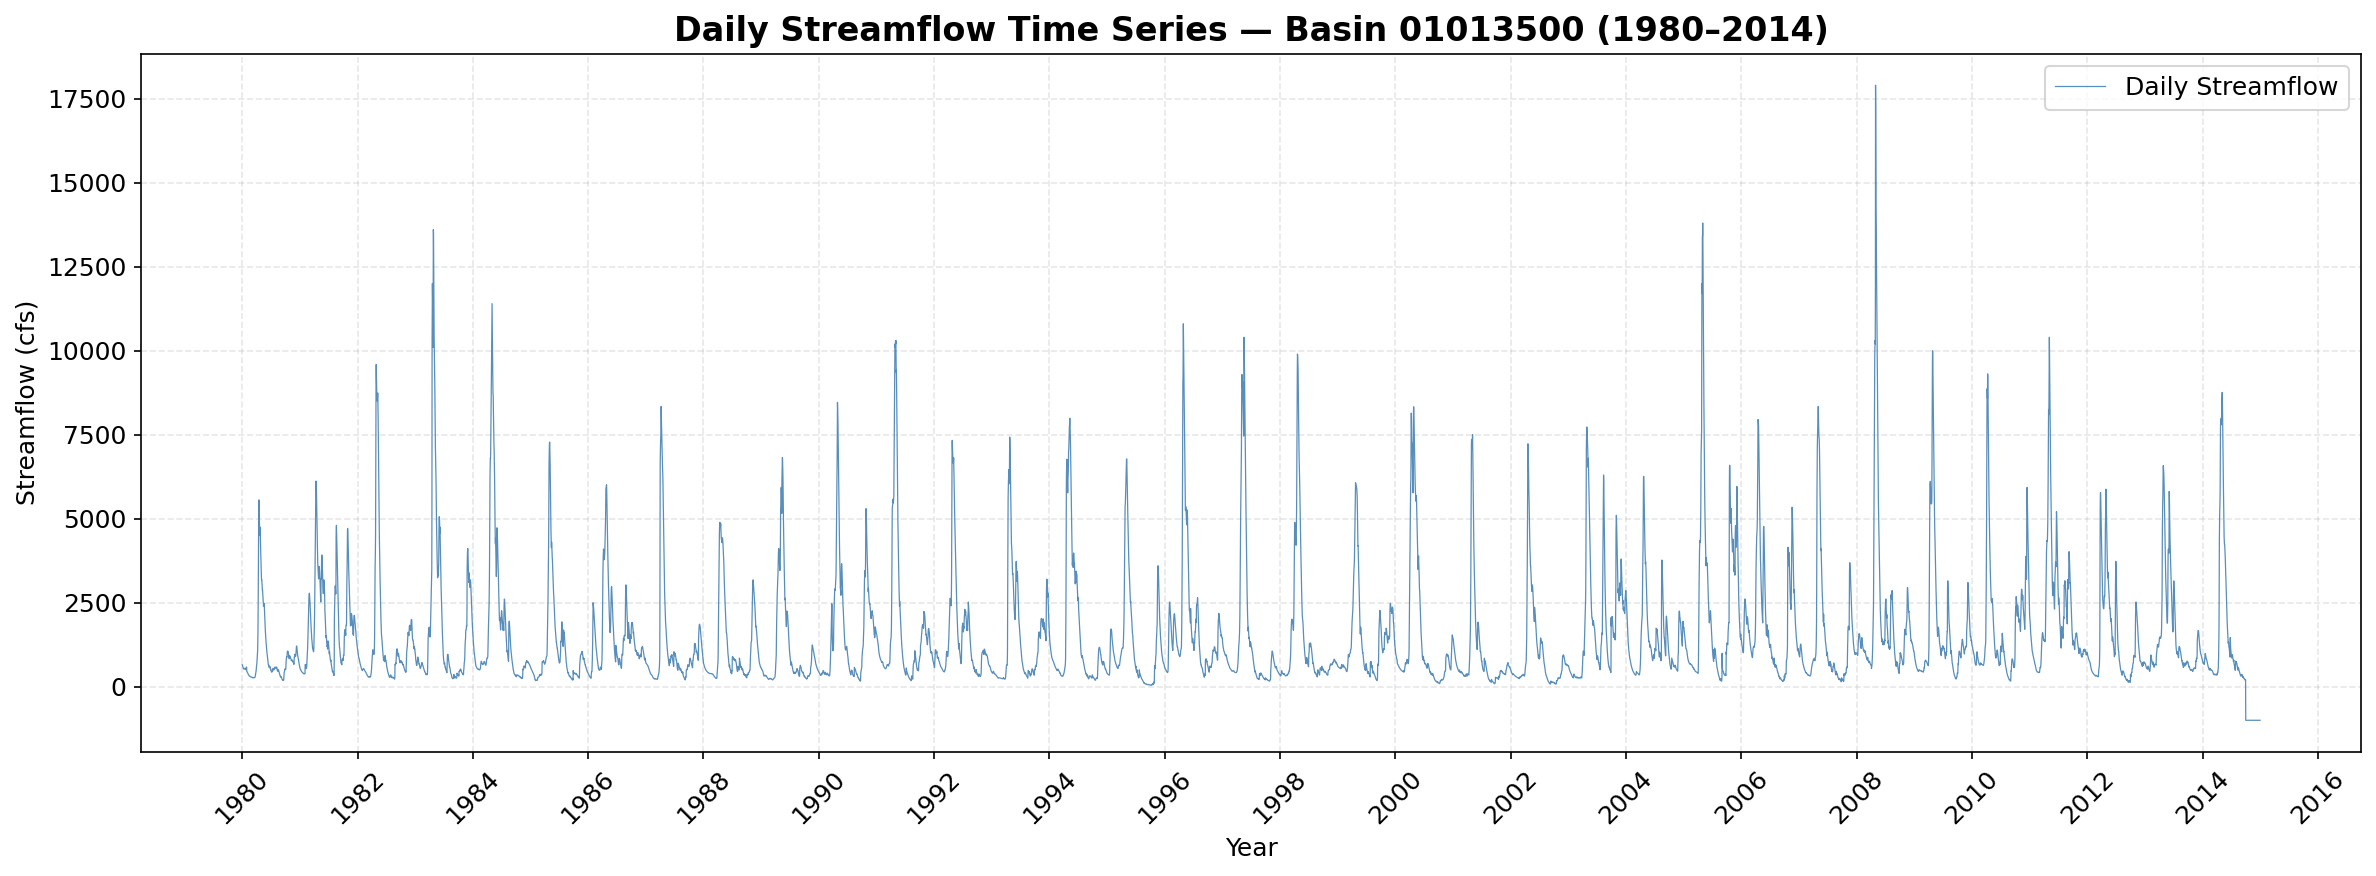

In [5]:
import matplotlib.dates as mdates

plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df["streamflow"],
        color="steelblue", linewidth=0.6, alpha=0.9,
        label="Daily Streamflow")

ax.set_title("Daily Streamflow Time Series — Basin 01013500 (1980–2014)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Streamflow (cfs)")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

ax.grid(True, alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()

plt.savefig("streamflow_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
print("تعداد نهایی داده‌های معتبر:", len(df))

تعداد نهایی داده‌های معتبر: 12784
